# Classification with a Perceptron — Calculating the Derivatives

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture that computes the **gradients** for
a classification perceptron (Week 3 — Optimization in Neural Networks and Newton's Method).

This is the payoff: the **sigmoid** and the **log loss** conspire so the gradients come out
remarkably clean.

This notebook explains:

- the chain-rule setup for $\partial L/\partial w_1, \partial L/\partial w_2, \partial L/\partial b$
- the derivative of the log loss $\partial L/\partial\hat{y} = -\dfrac{y-\hat{y}}{\hat{y}(1-\hat{y})}$
- the sigmoid derivatives $\partial\hat{y}/\partial w_i = \hat{y}(1-\hat{y})\,x_i$
- the **cancellation** giving $\partial L/\partial w_i = -(y-\hat{y})\,x_i$ and $\partial L/\partial b = -(y-\hat{y})$
- a SymPy verification, the gradient-descent updates, and a full training run

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Classification with a Perceptron — The Log Loss*.

## 1. The chain-rule setup

We want $\partial L/\partial w_1$, $\partial L/\partial w_2$, $\partial L/\partial b$ to run
gradient descent. As before, $L$ depends on $\hat{y}$, and $\hat{y}$ depends on each
parameter, so by the **chain rule**:

$$
\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial \hat{y}}\,\frac{\partial \hat{y}}{\partial w_1},
\qquad
\frac{\partial L}{\partial w_2} = \frac{\partial L}{\partial \hat{y}}\,\frac{\partial \hat{y}}{\partial w_2},
\qquad
\frac{\partial L}{\partial b} = \frac{\partial L}{\partial \hat{y}}\,\frac{\partial \hat{y}}{\partial b}.
$$

The shared factor $\partial L/\partial\hat{y}$ is computed once. Recall

$$
\hat{y} = \sigma(z),\quad z = w_1 x_1 + w_2 x_2 + b,\qquad
L = -y\log\hat{y} - (1-y)\log(1-\hat{y}).
$$

## 2. The derivative of the log loss, $\partial L/\partial\hat{y}$

Differentiate term by term (using $\frac{d}{d\hat y}\log\hat y = \frac{1}{\hat y}$ and
$\frac{d}{d\hat y}\log(1-\hat y) = \frac{-1}{1-\hat y}$):

$$
\frac{\partial L}{\partial \hat{y}}
= -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} .
$$

Putting over a common denominator, the numerator simplifies
($-y(1-\hat y) + (1-y)\hat y = \hat y - y$):

$$
\frac{\partial L}{\partial \hat{y}}
= \frac{\hat{y} - y}{\hat{y}(1-\hat{y})}
= -\,\frac{y - \hat{y}}{\hat{y}(1-\hat{y})} .
$$

## 3. The derivatives of $\hat{y}$

Since $\hat{y} = \sigma(z)$ and $\sigma'(z) = \sigma(z)(1-\sigma(z)) = \hat{y}(1-\hat{y})$,
the chain rule on $z = w_1 x_1 + w_2 x_2 + b$ gives

$$
\frac{\partial \hat{y}}{\partial w_1} = \hat{y}(1-\hat{y})\,x_1,\qquad
\frac{\partial \hat{y}}{\partial w_2} = \hat{y}(1-\hat{y})\,x_2,\qquad
\frac{\partial \hat{y}}{\partial b} = \hat{y}(1-\hat{y}).
$$

## 4. The beautiful cancellation

Multiply the shared factor by each $\partial\hat{y}/\partial(\cdot)$. The $\hat{y}(1-\hat{y})$
terms **cancel**:

$$
\frac{\partial L}{\partial w_1}
= -\frac{y-\hat{y}}{\hat{y}(1-\hat{y})}\cdot \hat{y}(1-\hat{y})\,x_1
= -(y - \hat{y})\,x_1 .
$$

So the gradients are

$$
\boxed{\;\frac{\partial L}{\partial w_1} = -(y-\hat{y})x_1,\quad
\frac{\partial L}{\partial w_2} = -(y-\hat{y})x_2,\quad
\frac{\partial L}{\partial b} = -(y-\hat{y}).\;}
$$

> *"These are exactly the same form as in the regression case."*

**Interpretation.** If $y$ and $\hat{y}$ are close, the gradient is tiny (the prediction is
already good); if they are far apart, the gradient is large (push hard).

## 5. Verifying with SymPy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

w1, w2, b, x1, x2, y = sp.symbols('w1 w2 b x1 x2 y', real=True)
z = w1*x1 + w2*x2 + b
y_hat = 1 / (1 + sp.exp(-z))
L = -y*sp.log(y_hat) - (1 - y)*sp.log(1 - y_hat)

# full chain-rule derivatives, simplified
dL_dw1 = sp.simplify(sp.diff(L, w1))
dL_db  = sp.simplify(sp.diff(L, b))

# expected clean forms
expected_w1 = sp.simplify(-(y - y_hat) * x1)
expected_b  = sp.simplify(-(y - y_hat))

print("∂L/∂w1 - (-(y - ŷ)·x1) =", sp.simplify(dL_dw1 - expected_w1), " (0 confirms)")
print("∂L/∂b  - (-(y - ŷ))     =", sp.simplify(dL_db  - expected_b),  " (0 confirms)")

∂L/∂w1 - (-(y - ŷ)·x1) = 0  (0 confirms)
∂L/∂b  - (-(y - ŷ))     = 0  (0 confirms)


## 6. Gradient descent for the classification perceptron

With the gradients in hand, the updates are

$$
w_1 \leftarrow w_1 + \alpha\,(y-\hat{y})x_1,\qquad
w_2 \leftarrow w_2 + \alpha\,(y-\hat{y})x_2,\qquad
b \leftarrow b + \alpha\,(y-\hat{y}).
$$

Let's train a classifier on the alien-sentiment data from the earlier lecture.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return np.mean(-y*np.log(p) - (1-y)*np.log(1-p))

# features [# aack, # beep]; label 1 = happy, 0 = sad
X = np.array([[3, 0], [0, 2], [1, 3], [2, 1]], dtype=float)
Y = np.array([1, 0, 0, 1], dtype=float)

def train(X, Y, alpha=0.5, epochs=2000):
    w = np.zeros(X.shape[1]); bias = 0.0
    losses = []
    for _ in range(epochs):
        y_hat = sigmoid(X @ w + bias)
        error = Y - y_hat                      # (y - y_hat)
        w    += alpha * (X.T @ error) / len(Y) # w  += α mean((y - ŷ) x)
        bias += alpha * np.mean(error)         # b  += α mean(y - ŷ)
        losses.append(log_loss(Y, y_hat))
    return w, bias, losses

w_t, b_t, losses = train(X, Y, alpha=0.5, epochs=3000)
print(f"trained weights: w1 = {w_t[0]:.3f}, w2 = {w_t[1]:.3f}, b = {b_t:.3f}")
print(f"final log loss : {losses[-1]:.5f}")

preds = sigmoid(X @ w_t + b_t)
for (a, bp), p, lab in zip(X, preds, Y):
    print(f"aack={a:.0f}, beep={bp:.0f}: ŷ={p:.3f} -> {'happy' if p>=0.5 else 'sad':5s} "
          f"(actual {'happy' if lab else 'sad'})")

trained weights: w1 = 5.182, w2 = -4.271, b = 0.485
final log loss : 0.00062
aack=3, beep=0: ŷ=1.000 -> happy (actual happy)
aack=0, beep=2: ŷ=0.000 -> sad   (actual sad)
aack=1, beep=3: ŷ=0.001 -> sad   (actual sad)
aack=2, beep=1: ŷ=0.999 -> happy (actual happy)


### Training loss and the learned decision boundary

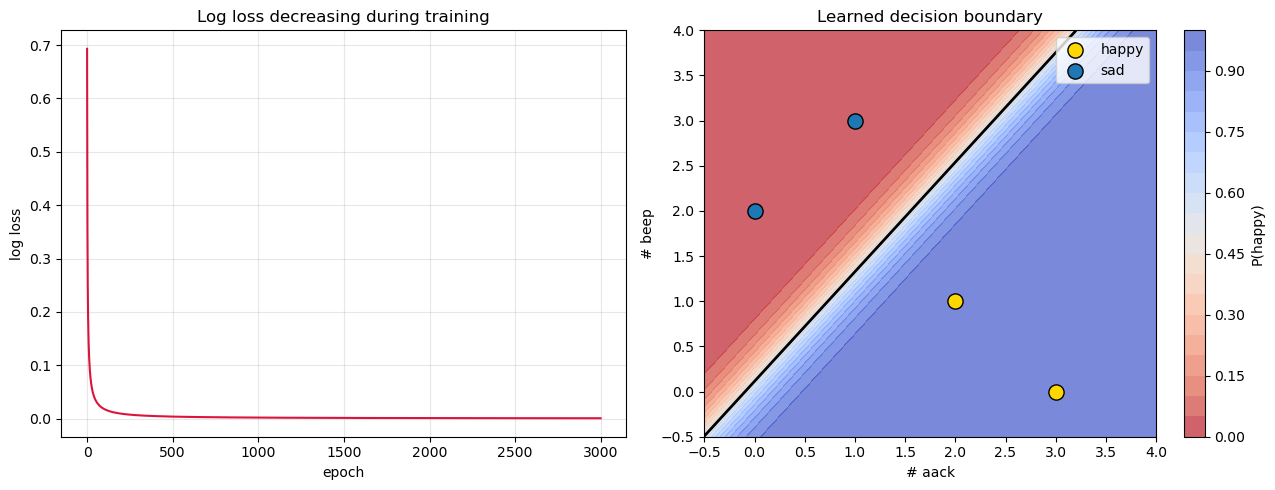

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(losses, color="crimson")
axes[0].set_title("Log loss decreasing during training")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("log loss")
axes[0].grid(True, alpha=0.3)

gx = np.linspace(-0.5, 4, 200); gy = np.linspace(-0.5, 4, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = sigmoid(w_t[0]*GX + w_t[1]*GY + b_t)
cf = axes[1].contourf(GX, GY, GZ, levels=20, cmap="coolwarm_r", alpha=0.7)
plt.colorbar(cf, ax=axes[1], label="P(happy)")
axes[1].contour(GX, GY, GZ, levels=[0.5], colors="black", linewidths=2)
happy = X[Y == 1]; sad = X[Y == 0]
axes[1].scatter(happy[:,0], happy[:,1], s=120, color="gold", edgecolor="black", label="happy")
axes[1].scatter(sad[:,0], sad[:,1], s=120, color="tab:blue", edgecolor="black", label="sad")
axes[1].set_title("Learned decision boundary")
axes[1].set_xlabel("# aack"); axes[1].set_ylabel("# beep"); axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Exercises

### Basic
1. Write the three log-loss gradients $\partial L/\partial w_1, \partial L/\partial w_2, \partial L/\partial b$.
2. What cancels to make them so simple?

### Intermediate
3. Compute $\partial L/\partial\hat{y}$ for the log loss and simplify it.
4. Show $\partial\hat{y}/\partial w_2 = \hat{y}(1-\hat{y})x_2$ using $\sigma' = \sigma(1-\sigma)$.

### Advanced
5. Verify with SymPy that $\partial L/\partial w_2 = -(y-\hat{y})x_2$.
6. The regression and classification perceptrons have the **same** gradient form
   $-(y-\hat{y})x_i$, despite different losses and activations. Explain why this is not a
   coincidence.

## 8. Solutions / Checks

In [4]:
yh = sp.symbols('yhat', positive=True)
L_simple = -y*sp.log(yh) - (1-y)*sp.log(1-yh)
print("3. ∂L/∂ŷ =", sp.simplify(sp.diff(L_simple, yh)), " = (ŷ - y)/(ŷ(1-ŷ))")

# 5. full check for w2
dL_dw2 = sp.simplify(sp.diff(L, w2))
print("5. ∂L/∂w2 + (y-ŷ)x2 =", sp.simplify(dL_dw2 + (y - y_hat)*x2), " (0 confirms)")

print("4. ∂ŷ/∂w2 = σ'(z)·∂z/∂w2 = ŷ(1-ŷ)·x2.")
print("6. With log loss + sigmoid, ∂L/∂ŷ has ŷ(1-ŷ) in its denominator and ∂ŷ/∂w has it in "
      "the numerator; they cancel, leaving the same -(y-ŷ)x form as squared-error + linear.")

3. ∂L/∂ŷ = (y - yhat)/(yhat*(yhat - 1))  = (ŷ - y)/(ŷ(1-ŷ))
5. ∂L/∂w2 + (y-ŷ)x2 = 0  (0 confirms)
4. ∂ŷ/∂w2 = σ'(z)·∂z/∂w2 = ŷ(1-ŷ)·x2.
6. With log loss + sigmoid, ∂L/∂ŷ has ŷ(1-ŷ) in its denominator and ∂ŷ/∂w has it in the numerator; they cancel, leaving the same -(y-ŷ)x form as squared-error + linear.


## 9. Conclusion

- The classification gradients come from the chain rule, and the sigmoid + log loss
  **cancel** to give

$$
\frac{\partial L}{\partial w_i} = -(y-\hat{y})\,x_i,\qquad
\frac{\partial L}{\partial b} = -(y-\hat{y}).
$$

- These have the **same form** as the regression perceptron's gradients — a tidy unifying
  result.
- The size of each gradient scales with the error $(y-\hat{y})$: small for good
  predictions, large for bad ones.
- Plugging them into gradient descent trains the classifier, as the alien-sentiment run
  shows. This single-neuron logic, chained across layers, is **backpropagation** — how full
  neural networks learn.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_07.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture **calculating the classification derivatives**. Key spoken
points, lightly cleaned:

> To do a gradient-descent step we need $\partial L/\partial w_1, \partial L/\partial w_2,
> \partial L/\partial b$. By the chain rule each is $\partial L/\partial\hat{y}$ times
> $\partial\hat{y}/\partial(\cdot)$, with $\hat{y} = \sigma(w_1x_1+w_2x_2+b)$ and the log
> loss $L = -y\log\hat{y} - (1-y)\log(1-\hat{y})$. The shared factor is
> $\partial L/\partial\hat{y} = -y/\hat{y} + (1-y)/(1-\hat{y})$, which combines to
> $-(y-\hat{y})/(\hat{y}(1-\hat{y}))$. Using $\sigma' = \sigma(1-\sigma)$,
> $\partial\hat{y}/\partial w_1 = \hat{y}(1-\hat{y})x_1$, and similarly for $w_2$ and $b$.
> Multiplying, the $\hat{y}(1-\hat{y})$ cancels and we get the clean derivatives
> $\partial L/\partial b = -(y-\hat{y})$, $\partial L/\partial w_1 = -(y-\hat{y})x_1$,
> $\partial L/\partial w_2 = -(y-\hat{y})x_2$ — the same form as regression. If $y$ and
> $\hat{y}$ are close the derivative is small; if far, large. Plug these into gradient
> descent and iterate to get good $w_1, w_2, b$.